# Drought Analysis and Prediction — LSTM Model

Computes SPI-3 and NDVI anomaly for KwaZulu-Natal and the Northern Cape (2000-2024) and trains a two-layer LSTM to predict SPI-3 one month ahead.

**Project:** Development and Evaluation of a Deep Learning Model for Flood Detection and Drought Prediction Using Satellite Remote Sensing Data in South Africa
**Study Area:** KwaZulu-Natal and Northern Cape, South Africa
**Period:** 2000-2024
**Student:** Athindothe Valencia Marubini
**Student No:** 219160643
**Supervisor:** Prof. I.E Davidson
**Co-Supervisor:** Dr O.P Babalola
**Institution:** Cape Peninsula University of Technology (CPUT)

Data sources (open access only):
- CHIRPS v2.0 — monthly rainfall at 0.05° resolution (Climate Hazards Group)
- MODIS MOD13A3 — monthly 1 km NDVI (NASA via Google Earth Engine)

Pipeline:
1. Download CHIRPS monthly rainfall for KZN and Northern Cape
2. Extract monthly NDVI means from MODIS via Google Earth Engine
3. Compute SPI-3 (gamma distribution fitting, per McKee et al. 1993)
4. Compute NDVI anomaly (deviation from long-term monthly climatology)
5. Train a two-layer LSTM to predict SPI-3 one month ahead
6. Evaluate and compare model performance across both provinces
7. Generate all thesis figures

Output folder: Drought_Thesis_Final/

## Cell 1 — Mount Drive and Install Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# rasterio for reading CHIRPS GeoTIFF files
!pip install rasterio scipy scikit-learn -q

import os
import gzip
import shutil
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import rasterio
from rasterio.windows import from_bounds
from scipy.stats import gamma as gamma_dist, norm
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cpu


## Cell 2 — Set Up Folder Structure



In [ ]:

ROOT = '/content/drive/MyDrive/Drought_Thesis_Final'

CHIRPS_KZN  = os.path.join(ROOT, 'CHIRPS', 'KZN')
CHIRPS_NC   = os.path.join(ROOT, 'CHIRPS', 'NorthernCape')
NDVI_DIR    = os.path.join(ROOT, 'MODIS_NDVI')
PROCESSED   = os.path.join(ROOT, 'Processed')
MODELS_DIR  = os.path.join(ROOT, 'Models')
FIGURES_DIR = os.path.join(ROOT, 'Figures')

for folder in [CHIRPS_KZN, CHIRPS_NC, NDVI_DIR, PROCESSED, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Folder structure created under:', ROOT)
for folder in [CHIRPS_KZN, CHIRPS_NC, NDVI_DIR, PROCESSED, MODELS_DIR, FIGURES_DIR]:
    print(f'  {os.path.relpath(folder, ROOT)}')

Folder structure created under: /content/drive/MyDrive/Drought_Thesis_Final
  CHIRPS/KZN
  CHIRPS/NorthernCape
  MODIS_NDVI
  Processed
  Models
  Figures


## Cell 3 — Study Area Definitions

Both provinces are defined by their bounding boxes in geographic coordinates (WGS84). These are used to spatially clip CHIRPS data during extraction.

The study period covers January 2000 to December 2024 — 300 months

In [ ]:
# bounding boxes: [lon_min, lat_min, lon_max, lat_max]
PROVINCES = {
    'KZN': {
        'label':  'KwaZulu-Natal',
        'bbox':   [28.8, -31.5, 32.9, -26.8],
        'color':  'steelblue',
    },
    'NC': {
        'label':  'Northern Cape',
        'bbox':   [16.5, -32.9, 25.5, -26.5],
        'color':  'darkorange',
    },
}

# full study period
MONTHS = pd.date_range(start='2000-01-01', end='2024-12-01', freq='MS')

print(f'Study period: {MONTHS[0].strftime("%B %Y")} to {MONTHS[-1].strftime("%B %Y")}')
print(f'Total months: {len(MONTHS)}')
print()
for key, info in PROVINCES.items():
    bb = info['bbox']
    print(f'{info["label"]} ({key})')
    print(f'  Bounding box: {bb[0]}E to {bb[2]}E, {abs(bb[1])}S to {abs(bb[3])}S')

Study period: January 2000 to December 2024
Total months: 300

KwaZulu-Natal (KZN)
  Bounding box: 28.8E to 32.9E, 31.5S to 26.8S
Northern Cape (NC)
  Bounding box: 16.5E to 25.5E, 32.9S to 26.5S


## Cell 4 — Download CHIRPS Monthly Rainfall

CHIRPS v2.0 monthly files are downloaded from the Climate Hazards Group public server. Each file is a compressed GeoTIFF (.tif.gz) covering the full African domain. Files are downloaded, decompressed, and stored locally in the CHIRPS folders created in Cell 2.



In [ ]:
CHIRPS_URL = 'https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_monthly/tifs'


def download_chirps(year, month, out_dir):
    """Download and decompress one monthly CHIRPS file.

    Returns the path to the decompressed .tif, or None if download failed.
    """
    filename = f'chirps-v2.0.{year}.{month:02d}.tif'
    tif_path = os.path.join(out_dir, filename)

    if os.path.exists(tif_path):
        return tif_path

    gz_path = tif_path + '.gz'
    url     = f'{CHIRPS_URL}/{filename}.gz'

    try:
        r = requests.get(url, timeout=90)
        if r.status_code != 200:
            return None
        with open(gz_path, 'wb') as f:
            f.write(r.content)
        with gzip.open(gz_path, 'rb') as gz_in, open(tif_path, 'wb') as tif_out:
            shutil.copyfileobj(gz_in, tif_out)
        os.remove(gz_path)
        return tif_path
    except Exception as e:
        print(f'  Error {year}-{month:02d}: {e}')
        return None



for key, info in PROVINCES.items():
    out_dir = CHIRPS_KZN if key == 'KZN' else CHIRPS_NC
    existing = len([f for f in os.listdir(out_dir) if f.endswith('.tif')])
    print(f'{info["label"]}: {existing}/{len(MONTHS)} files already present')

    downloaded = 0
    for dt in MONTHS:
        path = download_chirps(dt.year, dt.month, out_dir)
        if path and not os.path.exists(path.replace('.tif.gz', '.tif')):
            downloaded += 1

    total = len([f for f in os.listdir(out_dir) if f.endswith('.tif')])
    print(f'  {total}/{len(MONTHS)} files ready\n')

KwaZulu-Natal: 300/300 files already present
  300/300 files ready

Northern Cape: 300/300 files already present
  300/300 files ready



## Cell 5 — Extract Mean Rainfall per Province

For each CHIRPS file, the spatially averaged rainfall over the province bounding box is extracted using rasterio's windowed reading. CHIRPS uses -9999 as its nodata value, which is masked before computing the mean.

The result is one mean rainfall value per month per province, saved as a CSV.

In [ ]:
def extract_mean_rainfall(tif_path, bbox):
    """Extract mean rainfall (mm/month) within a bounding box.

    CHIRPS nodata is -9999 — these pixels are excluded from the mean.
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    with rasterio.open(tif_path) as src:
        window = from_bounds(lon_min, lat_min, lon_max, lat_max, src.transform)
        data   = src.read(1, window=window).astype(np.float32)
    data[data < -100] = np.nan
    return float(np.nanmean(data))


rainfall = {}   # will hold DataFrames keyed by province code

for key, info in PROVINCES.items():
    csv_out = os.path.join(PROCESSED, f'rainfall_{key}.csv')

    if os.path.exists(csv_out):
        rainfall[key] = pd.read_csv(csv_out, parse_dates=['date'])
        print(f'[loaded] {os.path.basename(csv_out)} ({len(rainfall[key])} months)')
        continue

    chirps_dir = CHIRPS_KZN if key == 'KZN' else CHIRPS_NC
    records    = []

    for dt in MONTHS:
        fname = f'chirps-v2.0.{dt.year}.{dt.month:02d}.tif'
        fpath = os.path.join(chirps_dir, fname)
        if os.path.exists(fpath):
            mean_rain = extract_mean_rainfall(fpath, info['bbox'])
        else:
            mean_rain = np.nan
        records.append({'date': dt, 'rainfall_mm': mean_rain})

    df = pd.DataFrame(records)
    df.to_csv(csv_out, index=False)
    rainfall[key] = df
    print(f'Saved: {os.path.basename(csv_out)}')

print()
for key, df in rainfall.items():
    print(f'{PROVINCES[key]["label"]}: mean rainfall = {df["rainfall_mm"].mean():.1f} mm/month')

[loaded] rainfall_KZN.csv (300 months)
[loaded] rainfall_NC.csv (300 months)

KwaZulu-Natal: mean rainfall = 65.3 mm/month
Northern Cape: mean rainfall = 18.6 mm/month


## Cell 6 — Extract MODIS NDVI via Google Earth Engine

Monthly mean NDVI was extracted from the MODIS MOD13A3 product (collection MODIS/061/MOD13A3) using the Google Earth Engine Python API. The reduceRegion method computes the spatial mean over each province boundary for every monthly image in the collection.


In [ ]:

try:
    import ee
    GEE_AVAILABLE = True
except ImportError:
    GEE_AVAILABLE = False
    print('earthengine-api not installed. Installing...')

if not GEE_AVAILABLE:
    !pip install earthengine-api -q
    import ee

import ee
ee.Authenticate()
ee.Initialize(project='kzn-flood-research')
print('GEE authenticated.')


def extract_modis_ndvi(province_key, bbox, start='2000-01-01', end='2024-12-31'):
    """Extract monthly mean NDVI from MODIS MOD13A3 for a bounding box.

    MODIS NDVI is stored as scaled integers (multiply by 0.0001 for actual values).
    Returns a DataFrame with columns: date, ndvi.
    """
    csv_out = os.path.join(PROCESSED, f'ndvi_{province_key}.csv')
    if os.path.exists(csv_out):
        df = pd.read_csv(csv_out, parse_dates=['date'])
        print(f'[loaded] {os.path.basename(csv_out)} ({len(df)} months)')
        return df

    lon_min, lat_min, lon_max, lat_max = bbox
    region = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])

    collection = (
        ee.ImageCollection('MODIS/061/MOD13A3')
        .filterDate(start, end)
        .filterBounds(region)
        .select('NDVI')
    )

    def get_monthly_mean(image):
        mean = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=1000,
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'date': image.date().format('YYYY-MM-dd'),
            'ndvi': mean.get('NDVI')
        })

    features  = collection.map(get_monthly_mean)
    fc        = ee.FeatureCollection(features)
    info_list = fc.getInfo()['features']

    records = []
    for feat in info_list:
        props = feat['properties']
        ndvi_raw = props.get('ndvi')
        if ndvi_raw is not None:
            records.append({
                'date': pd.to_datetime(props['date']),
                'ndvi': float(ndvi_raw) * 0.0001   # MODIS scale factor
            })

    df = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
    df['ndvi'] = df['ndvi'].clip(-0.2, 1.0)
    df.to_csv(csv_out, index=False)
    print(f'Saved: {os.path.basename(csv_out)} ({len(df)} months)')
    return df


ndvi = {}
for key, info in PROVINCES.items():
    ndvi[key] = extract_modis_ndvi(key, info['bbox'])
    print(f'  {info["label"]}: mean NDVI = {ndvi[key]["ndvi"].mean():.3f}')

GEE authenticated.
[loaded] ndvi_KZN.csv (299 months)
  KwaZulu-Natal: mean NDVI = 0.530
[loaded] ndvi_NC.csv (299 months)
  Northern Cape: mean NDVI = 0.201


## Cell 7 — Compute SPI-3

The Standardised Precipitation Index at the 3-month scale (SPI-3) is computed. The procedure is:

1. Compute 3-month rolling rainfall totals
2. Fit a two-parameter gamma distribution to each calendar month separately (to account for South Africa's strong seasonality)
3. Convert the cumulative probability to a standard normal variate using the inverse normal CDF

SPI-3 captures short-to-medium term moisture conditions relevant to agricultural drought. Drought thresholds follow the WMO (2012) classification.

In [ ]:
# WMO drought severity thresholds
SPI_THRESHOLDS = [
    ( 0.0,  float('inf'), 'Normal / Wet',      '#4393c3'),
    (-1.0,  0.0,          'Mild drought',       '#fee090'),
    (-1.5, -1.0,          'Moderate drought',   '#fc8d59'),
    (-2.0, -1.5,          'Severe drought',     '#d73027'),
    (-float('inf'), -2.0, 'Extreme drought',    '#7a0000'),
]


def classify_spi(value):
    for low, high, label, _ in SPI_THRESHOLDS:
        if low <= value < high:
            return label
    return 'Extreme drought'


def compute_spi3(rainfall_df):
    """Compute SPI-3 from a monthly rainfall DataFrame.

    Parameters
    ----------
    rainfall_df : DataFrame with columns 'date' and 'rainfall_mm'

    Returns
    -------
    DataFrame with columns: date, rainfall_mm, rolling3, spi3, drought_class
    """
    df = rainfall_df.copy().set_index('date').sort_index()
    df['rolling3'] = df['rainfall_mm'].rolling(3).sum()

    spi_vals = pd.Series(index=df.index, dtype=float)

    for month in range(1, 13):
        mask   = df.index.month == month
        values = df.loc[mask, 'rolling3'].dropna().values
        values = values[values > 0]

        if len(values) < 10:
            continue

        # fit gamma — loc fixed at 0 (rainfall cannot be negative)
        shape, loc, scale = gamma_dist.fit(values, floc=0)

        # probability of non-exceedance, then convert to standard normal
        p = gamma_dist.cdf(df.loc[mask, 'rolling3'], shape, loc=loc, scale=scale)
        p = np.clip(p, 1e-6, 1 - 1e-6)   # avoid +/-inf from norm.ppf
        spi_vals[mask] = norm.ppf(p)

    df['spi3'] = spi_vals
    df = df.dropna(subset=['spi3']).reset_index()
    df['drought_class'] = df['spi3'].apply(classify_spi)
    return df


spi = {}
for key, info in PROVINCES.items():
    spi[key] = compute_spi3(rainfall[key])

    worst = spi[key].loc[spi[key]['spi3'].idxmin()]
    n_mild    = (spi[key]['spi3'] < -1.0).sum()
    n_severe  = (spi[key]['spi3'] < -1.5).sum()
    n_extreme = (spi[key]['spi3'] < -2.0).sum()

    print(f'{info["label"]}')
    print(f'  SPI-3 range: {spi[key]["spi3"].min():.3f} to {spi[key]["spi3"].max():.3f}')
    print(f'  Worst month: {worst["date"].strftime("%B %Y")} (SPI-3 = {worst["spi3"]:.3f})')
    print(f'  Mild drought months (SPI < -1.0):    {n_mild}')
    print(f'  Severe drought months (SPI < -1.5):  {n_severe}')
    print(f'  Extreme drought months (SPI < -2.0): {n_extreme}')
    print()

    # save processed SPI to CSV
    spi[key].to_csv(os.path.join(PROCESSED, f'spi3_{key}.csv'), index=False)

KwaZulu-Natal
  SPI-3 range: -2.436 to 3.015
  Worst month: January 2016 (SPI-3 = -2.436)
  Mild drought months (SPI < -1.0):    56
  Severe drought months (SPI < -1.5):  15
  Extreme drought months (SPI < -2.0): 5

Northern Cape
  SPI-3 range: -2.161 to 2.454
  Worst month: September 2017 (SPI-3 = -2.161)
  Mild drought months (SPI < -1.0):    48
  Severe drought months (SPI < -1.5):  20
  Extreme drought months (SPI < -2.0): 5



## Cell 8 — Compute NDVI Anomaly

The NDVI anomaly is defined as the departure of monthly NDVI from the long-term climatological mean for the same calendar month. This removes the seasonal cycle and isolates drought-driven vegetation stress:



In [ ]:
ndvi_anom = {}

for key, info in PROVINCES.items():
    df = ndvi[key].copy()
    df['month'] = df['date'].dt.month

    # long-term monthly climatology
    clim = df.groupby('month')['ndvi'].mean().rename('ndvi_clim')
    df   = df.join(clim, on='month')

    df['ndvi_anomaly'] = df['ndvi'] - df['ndvi_clim']

    ndvi_anom[key] = df[['date', 'ndvi', 'ndvi_clim', 'ndvi_anomaly']]

    print(f'{info["label"]}')
    print(f'  NDVI mean:           {df["ndvi"].mean():.3f}')
    print(f'  Anomaly range:       {df["ndvi_anomaly"].min():.3f} to {df["ndvi_anomaly"].max():.3f}')
    print(f'  Negative anomaly months: {(df["ndvi_anomaly"] < 0).sum()}')
    print()

    ndvi_anom[key].to_csv(os.path.join(PROCESSED, f'ndvi_anomaly_{key}.csv'), index=False)

KwaZulu-Natal
  NDVI mean:           0.530
  Anomaly range:       -0.141 to 0.079
  Negative anomaly months: 145

Northern Cape
  NDVI mean:           0.201
  Anomaly range:       -0.038 to 0.067
  Negative anomaly months: 158



## Cell 9 — Figure: SPI-3 Time Series

SPI-3 is plotted for the full 2000–2024 period for both provinces. Bars are coloured by drought severity class. The El Niño 2015/2016 drought — the most severe in the record — is annotated.

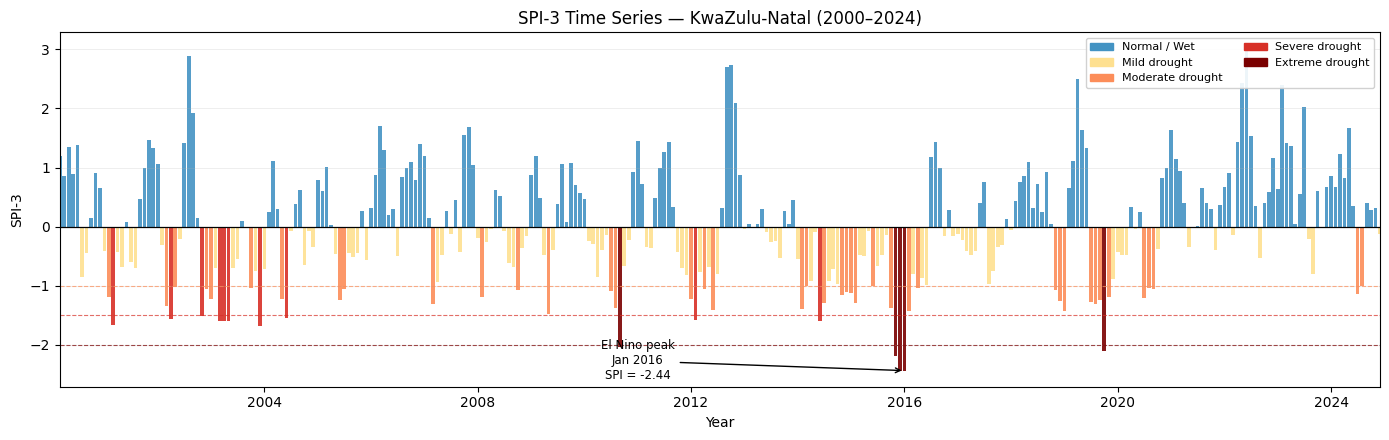

  Saved: SPI3_timeseries_KZN.png


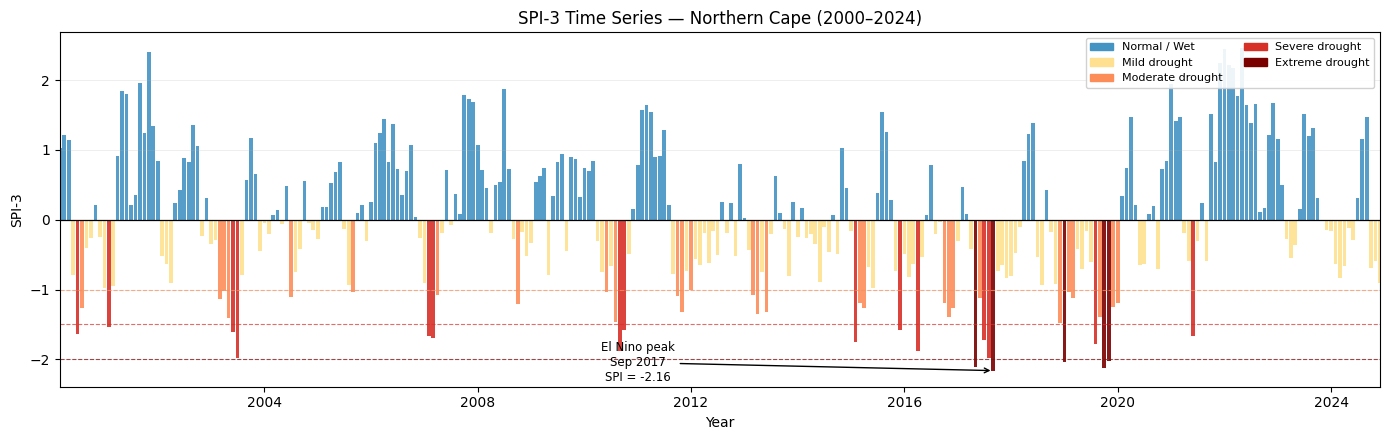

  Saved: SPI3_timeseries_NC.png


In [ ]:
COLOR_MAP = {label: color for _, _, label, color in SPI_THRESHOLDS}


def plot_spi_series(df_spi, province_label, color_map, save_path):
    fig, ax = plt.subplots(figsize=(14, 4.5))

    for _, row in df_spi.iterrows():
        ax.bar(
            row['date'], row['spi3'],
            color=color_map.get(row['drought_class'], 'gray'),
            width=25, align='center', alpha=0.9
        )

    # reference lines
    ax.axhline(0,    color='black',   linewidth=0.9)
    ax.axhline(-1.0, color='#fc8d59', linewidth=0.8, linestyle='--', alpha=0.7, label='Mild (-1.0)')
    ax.axhline(-1.5, color='#d73027', linewidth=0.8, linestyle='--', alpha=0.7, label='Severe (-1.5)')
    ax.axhline(-2.0, color='#7a0000', linewidth=0.8, linestyle='--', alpha=0.7, label='Extreme (-2.0)')

    # annotate worst drought
    worst = df_spi.loc[df_spi['spi3'].idxmin()]
    ax.annotate(
        f'El Nino peak\n{worst["date"].strftime("%b %Y")}\nSPI = {worst["spi3"]:.2f}',
        xy=(worst['date'], worst['spi3']),
        xytext=(pd.Timestamp('2011-01-01'), worst['spi3'] - 0.15),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
        fontsize=8.5, ha='center'
    )

    # legend for drought classes
    handles = [mpatches.Patch(color=c, label=l) for _, _, l, c in SPI_THRESHOLDS]
    ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=2, framealpha=0.9)

    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('SPI-3', fontsize=10)
    ax.set_title(f'SPI-3 Time Series — {province_label} (2000–2024)', fontsize=12)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(df_spi['date'].min(), df_spi['date'].max())
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {os.path.basename(save_path)}')


for key, info in PROVINCES.items():
    plot_spi_series(
        spi[key],
        info['label'],
        COLOR_MAP,
        save_path=os.path.join(FIGURES_DIR, f'SPI3_timeseries_{key}.png')
    )

## Cell 10 — Figure: NDVI Anomaly Time Series

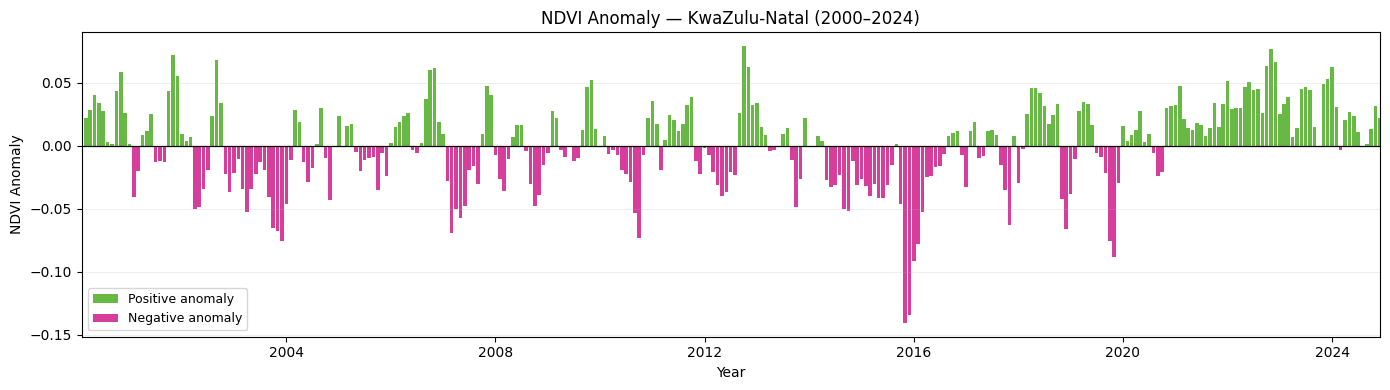

  Saved: NDVI_anomaly_KZN.png


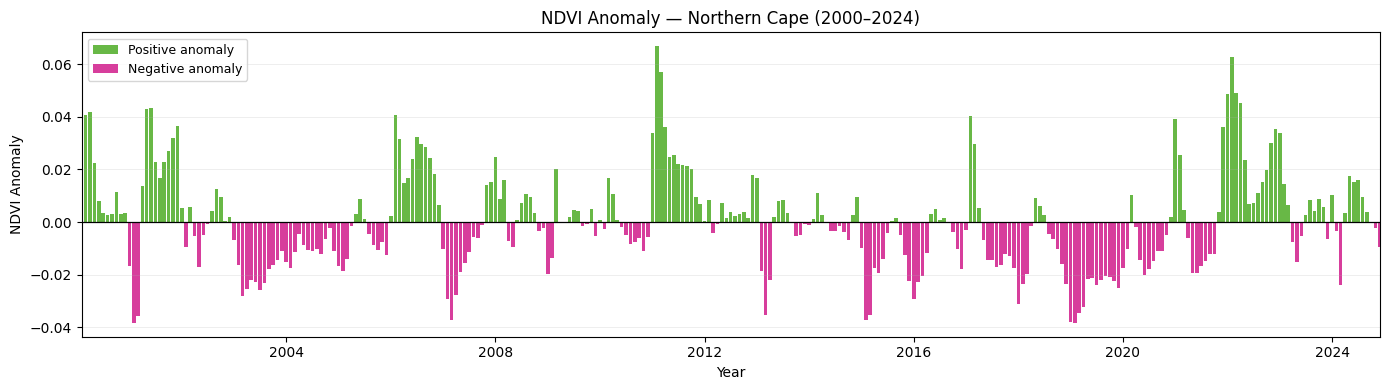

  Saved: NDVI_anomaly_NC.png


In [ ]:
def plot_ndvi_anomaly(df_ndvi, province_label, save_path):
    fig, ax = plt.subplots(figsize=(14, 4))

    pos  = df_ndvi['ndvi_anomaly'] >= 0
    neg  = ~pos

    ax.bar(df_ndvi.loc[pos, 'date'], df_ndvi.loc[pos, 'ndvi_anomaly'],
           color='#4dac26', width=25, label='Positive anomaly', alpha=0.85)
    ax.bar(df_ndvi.loc[neg, 'date'], df_ndvi.loc[neg, 'ndvi_anomaly'],
           color='#d01c8b', width=25, label='Negative anomaly', alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.9)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('NDVI Anomaly', fontsize=10)
    ax.set_title(f'NDVI Anomaly — {province_label} (2000–2024)', fontsize=12)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(df_ndvi['date'].min(), df_ndvi['date'].max())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {os.path.basename(save_path)}')


for key, info in PROVINCES.items():
    plot_ndvi_anomaly(
        ndvi_anom[key],
        info['label'],
        save_path=os.path.join(FIGURES_DIR, f'NDVI_anomaly_{key}.png')
    )

## Cell 11 — Figure: SPI-3 and NDVI Anomaly Comparison

A dual-panel figure showing SPI-3 and NDVI anomaly together for each province. This illustrates the relationship between rainfall deficit and vegetation response — a key result for the thesis.

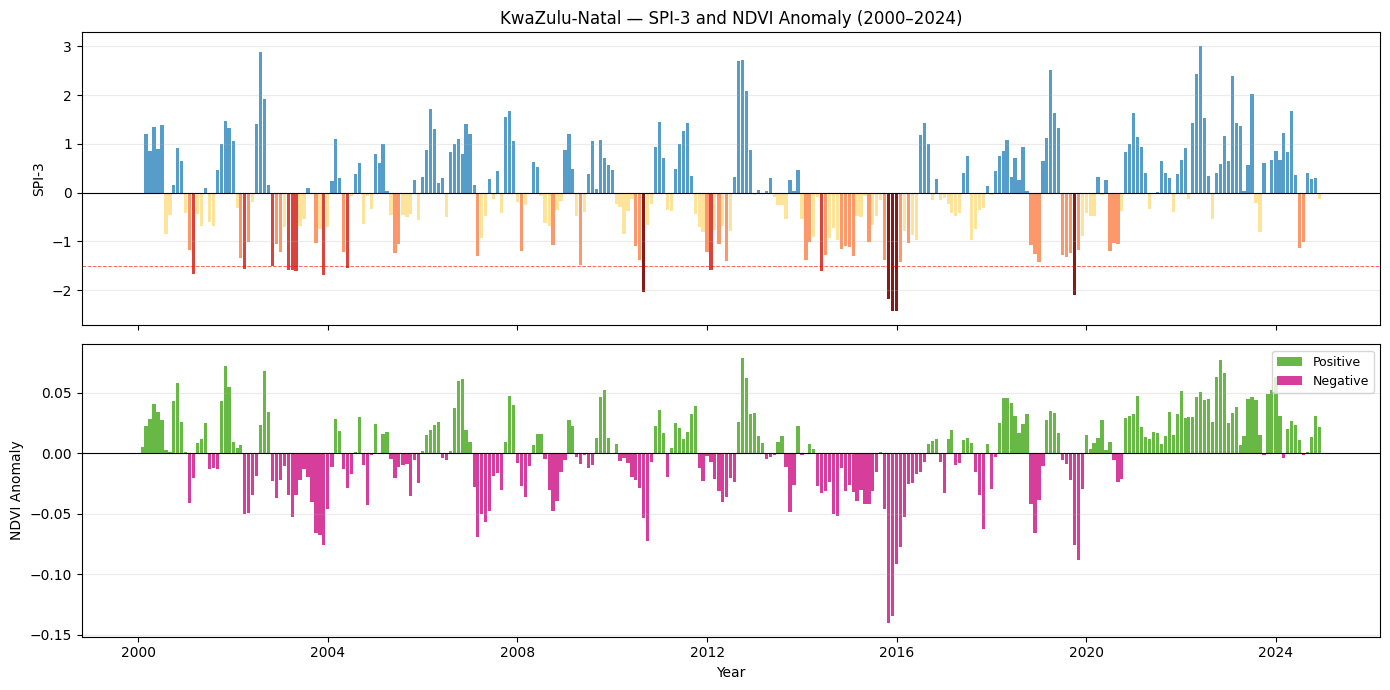

  Saved: SPI_NDVI_combined_KZN.png


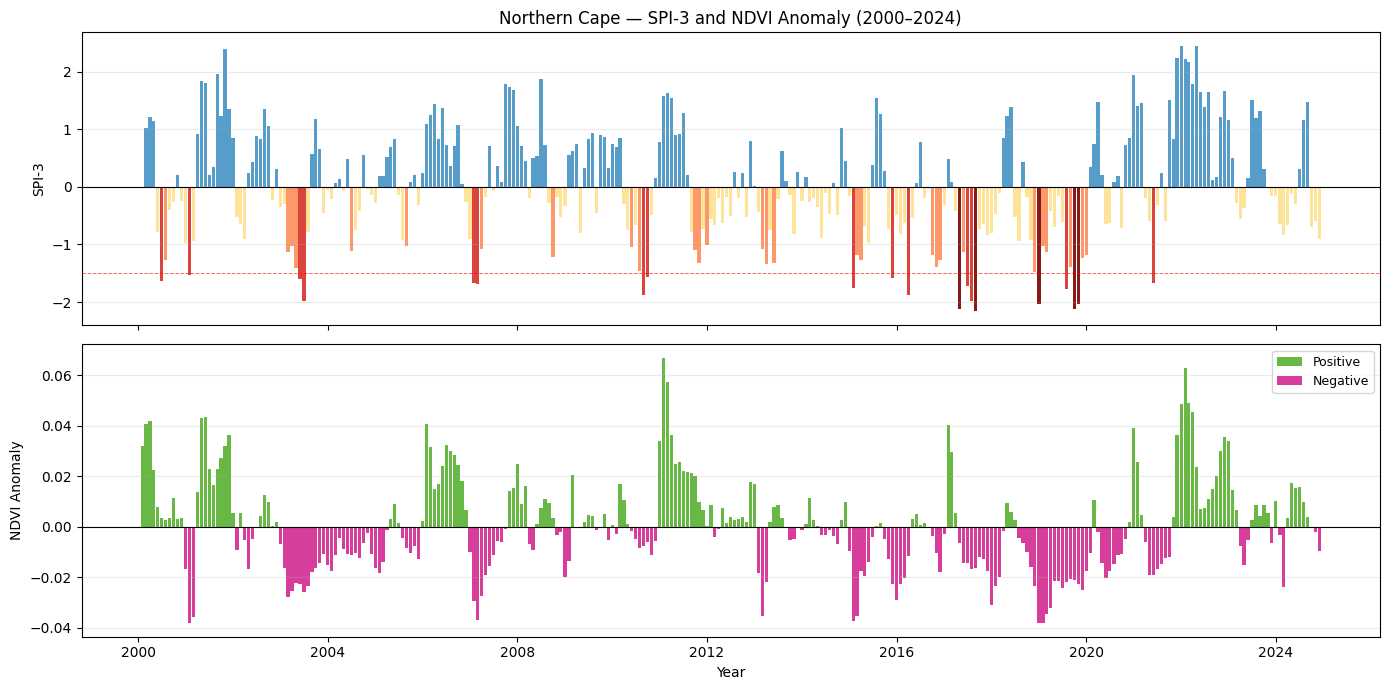

  Saved: SPI_NDVI_combined_NC.png


In [ ]:
def plot_spi_ndvi_comparison(df_spi, df_ndvi, province_label, save_path):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # SPI-3
    for _, row in df_spi.iterrows():
        ax1.bar(row['date'], row['spi3'],
                color=COLOR_MAP.get(row['drought_class'], 'gray'),
                width=25, align='center', alpha=0.9)
    ax1.axhline(0,    color='black', linewidth=0.8)
    ax1.axhline(-1.5, color='red', linewidth=0.7, linestyle='--', alpha=0.6)
    ax1.set_ylabel('SPI-3', fontsize=10)
    ax1.set_title(f'{province_label} — SPI-3 and NDVI Anomaly (2000–2024)', fontsize=12)
    ax1.grid(axis='y', alpha=0.25)

    # NDVI anomaly
    pos = df_ndvi['ndvi_anomaly'] >= 0
    ax2.bar(df_ndvi.loc[pos, 'date'],  df_ndvi.loc[pos,  'ndvi_anomaly'],
            color='#4dac26', width=25, alpha=0.85, label='Positive')
    ax2.bar(df_ndvi.loc[~pos, 'date'], df_ndvi.loc[~pos, 'ndvi_anomaly'],
            color='#d01c8b', width=25, alpha=0.85, label='Negative')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Year', fontsize=10)
    ax2.set_ylabel('NDVI Anomaly', fontsize=10)
    ax2.legend(fontsize=9, loc='upper right')
    ax2.grid(axis='y', alpha=0.25)

    ax2.xaxis.set_major_locator(mdates.YearLocator(4))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {os.path.basename(save_path)}')


for key, info in PROVINCES.items():
    plot_spi_ndvi_comparison(
        spi[key], ndvi_anom[key],
        info['label'],
        save_path=os.path.join(FIGURES_DIR, f'SPI_NDVI_combined_{key}.png')
    )

## Cell 12 — Merge and Prepare LSTM Input

SPI-3 and NDVI anomaly are merged on year-month into a single time series. The two features are normalised to the 0–1 range using Min-Max scaling. The scaler is fitted on the training portion only to prevent information leakage.



In [ ]:
SEQ_LEN = 12   # 12-month input window -> predict month 13


def merge_features(df_spi, df_ndvi_anom):
    """Merge SPI-3 and NDVI anomaly on year-month."""
    a = df_spi[['date', 'spi3']].copy()
    b = df_ndvi_anom[['date', 'ndvi_anomaly']].copy()
    a['ym'] = a['date'].dt.to_period('M')
    b['ym'] = b['date'].dt.to_period('M')
    merged  = pd.merge(a, b, on='ym')
    merged  = merged[['date_x', 'spi3', 'ndvi_anomaly']].rename(columns={'date_x': 'date'})
    return merged.dropna().sort_values('date').reset_index(drop=True)


def build_sequences(df):
    """Scale features and build sliding-window sequences.

    Returns train, val, test arrays plus the fitted scaler and test dates.
    """
    n      = len(df)
    n_tr   = int(0.70 * n)
    n_vl   = int(0.15 * n)

    feat_cols = ['spi3', 'ndvi_anomaly']
    scaler    = MinMaxScaler()

    train_vals = scaler.fit_transform(df.iloc[:n_tr][feat_cols].values)
    val_vals   = scaler.transform(df.iloc[n_tr:n_tr+n_vl][feat_cols].values)
    test_vals  = scaler.transform(df.iloc[n_tr+n_vl:][feat_cols].values)

    all_vals  = np.vstack([train_vals, val_vals, test_vals])
    all_dates = df['date'].values

    def make_xy(start, end):
        X_list, y_list = [], []
        for i in range(max(SEQ_LEN, start), end):
            X_list.append(all_vals[i - SEQ_LEN:i])
            y_list.append(all_vals[i, 0])  # SPI-3 is index 0
        return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

    X_tr, y_tr = make_xy(0,          n_tr)
    X_vl, y_vl = make_xy(n_tr,       n_tr + n_vl)
    X_te, y_te = make_xy(n_tr + n_vl, n)

    test_dates = all_dates[n_tr + n_vl + SEQ_LEN:]

    return X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_dates


combined   = {}
sequences  = {}

for key, info in PROVINCES.items():
    combined[key]  = merge_features(spi[key], ndvi_anom[key])
    sequences[key] = build_sequences(combined[key])

    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_dates = sequences[key]
    print(f'{info["label"]}: {len(combined[key])} months merged')
    print(f'  Train: {len(X_tr)}  Val: {len(X_vl)}  Test: {len(X_te)} sequences')

KwaZulu-Natal: 298 months merged
  Train: 196  Val: 44  Test: 46 sequences
Northern Cape: 298 months merged
  Train: 196  Val: 44  Test: 46 sequences


## Cell 13 — LSTM Architecture

A two-layer LSTM with dropout is used for drought prediction. The model takes a 12-month sequence of two features (SPI-3 and NDVI anomaly) and outputs the predicted SPI-3 value for the following month.



In [ ]:
class DroughtLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,   # applied between LSTM layers
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # only the final hidden state is used for prediction
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :]).squeeze(1)


# check parameter count
test_model = DroughtLSTM()
n_params   = sum(p.numel() for p in test_model.parameters())
print(f'LSTM parameters: {n_params:,}')
del test_model

LSTM parameters: 50,753


## Cell 14 — Dataset Class

A simple PyTorch Dataset wraps the numpy arrays for use with DataLoader.

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


print('SequenceDataset defined.')

SequenceDataset defined.


## Cell 15 — Train LSTM for Both Provinces

The same training configuration is applied to both provinces to keep the comparison fair:
- Loss: mean squared error
- Optimiser: Adam, learning rate 1e-3
- Scheduler: ReduceLROnPlateau (factor 0.5, patience 5 epochs)
- Early stopping: patience 15 epochs
- Best checkpoint saved per province

In [ ]:
N_EPOCHS = 150
PATIENCE = 15

lstm_results = {}


def train_province(key, label, seqs):
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_dates = seqs

    train_loader = DataLoader(SequenceDataset(X_tr, y_tr), batch_size=16, shuffle=True)
    val_loader   = DataLoader(SequenceDataset(X_vl, y_vl), batch_size=16, shuffle=False)

    model     = DroughtLSTM().to(DEVICE)
    criterion = nn.MSELoss()
    optimiser = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=0.5, patience=5
    )

    best_val   = float('inf')
    no_improve = 0
    train_hist = []
    val_hist   = []
    model_path = os.path.join(MODELS_DIR, f'lstm_{key}.pth')

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        tr_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimiser.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl_loss += criterion(model(Xb), yb).item()
        vl_loss /= len(val_loader)

        train_hist.append(tr_loss)
        val_hist.append(vl_loss)
        scheduler.step(vl_loss)

        if vl_loss < best_val:
            best_val   = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            no_improve += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f'  [{label}] Epoch {epoch:4d}  train={tr_loss:.5f}  val={vl_loss:.5f}')

        if no_improve >= PATIENCE:
            print(f'  [{label}] Early stop at epoch {epoch}')
            break

    # evaluate on test set using best checkpoint
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    with torch.no_grad():
        y_pred_scaled = model(
            torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    # inverse transform back to original SPI-3 scale
    def inv_spi(scaled_vals):
        dummy = np.zeros((len(scaled_vals), 2), dtype=np.float32)
        dummy[:, 0] = scaled_vals
        return scaler.inverse_transform(dummy)[:, 0]

    y_true_orig = inv_spi(y_te)
    y_pred_orig = inv_spi(y_pred_scaled)

    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2   = r2_score(y_true_orig, y_pred_orig)
    r, _ = pearsonr(y_true_orig, y_pred_orig)

    print(f'\n  [{label}] Test: RMSE={rmse:.4f}  R2={r2:.4f}  r={r:.4f}\n')

    return {
        'train_hist':  train_hist,
        'val_hist':    val_hist,
        'y_true':      y_true_orig,
        'y_pred':      y_pred_orig,
        'test_dates':  pd.to_datetime(test_dates),
        'rmse':        rmse,
        'r2':          r2,
        'r':           r,
        'model_path':  model_path,
    }


for key, info in PROVINCES.items():
    lstm_results[key] = train_province(key, info['label'], sequences[key])

  [KwaZulu-Natal] Epoch    1  train=0.09998  val=0.03592
  [KwaZulu-Natal] Epoch   25  train=0.02067  val=0.01719
  [KwaZulu-Natal] Epoch   50  train=0.01384  val=0.01643
  [KwaZulu-Natal] Early stop at epoch 60

  [KwaZulu-Natal] Test: RMSE=0.8003  R2=0.1318  r=0.5247

  [Northern Cape] Epoch    1  train=0.13727  val=0.05881
  [Northern Cape] Epoch   25  train=0.03181  val=0.04667
  [Northern Cape] Epoch   50  train=0.02503  val=0.03469
  [Northern Cape] Epoch   75  train=0.02294  val=0.02924
  [Northern Cape] Early stop at epoch 81

  [Northern Cape] Test: RMSE=0.8285  R2=0.3888  r=0.7495



## Cell 16 — Figure: Training Curves

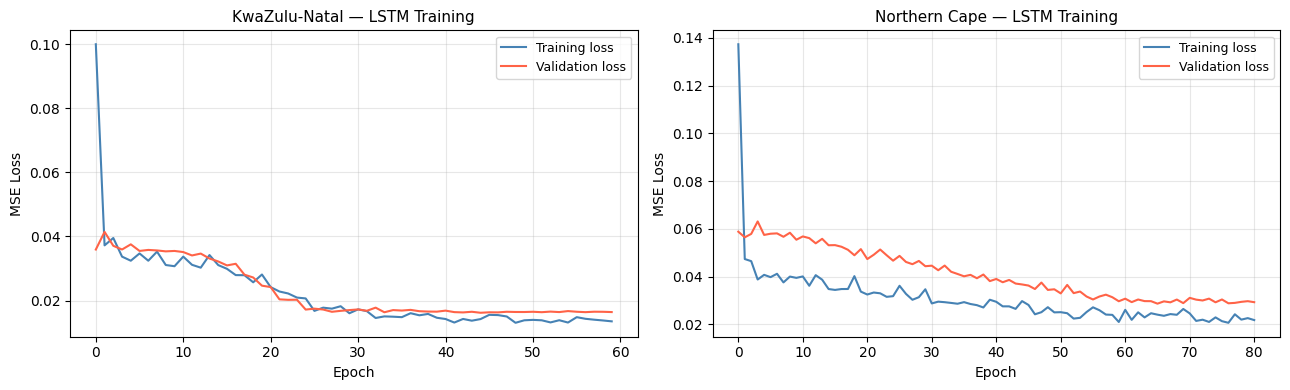

Saved: LSTM_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (key, res) in zip(axes, lstm_results.items()):
    ax.plot(res['train_hist'], color='steelblue', label='Training loss')
    ax.plot(res['val_hist'],   color='tomato',    label='Validation loss')
    ax.set_title(f'{PROVINCES[key]["label"]} — LSTM Training', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'LSTM_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: LSTM_training_curves.png')

## Cell 17 — Figure: Predicted vs Actual SPI-3

The model predictions on the held-out test set are plotted against the actual SPI-3 values. The dashed threshold lines help assess whether drought events are correctly captured.

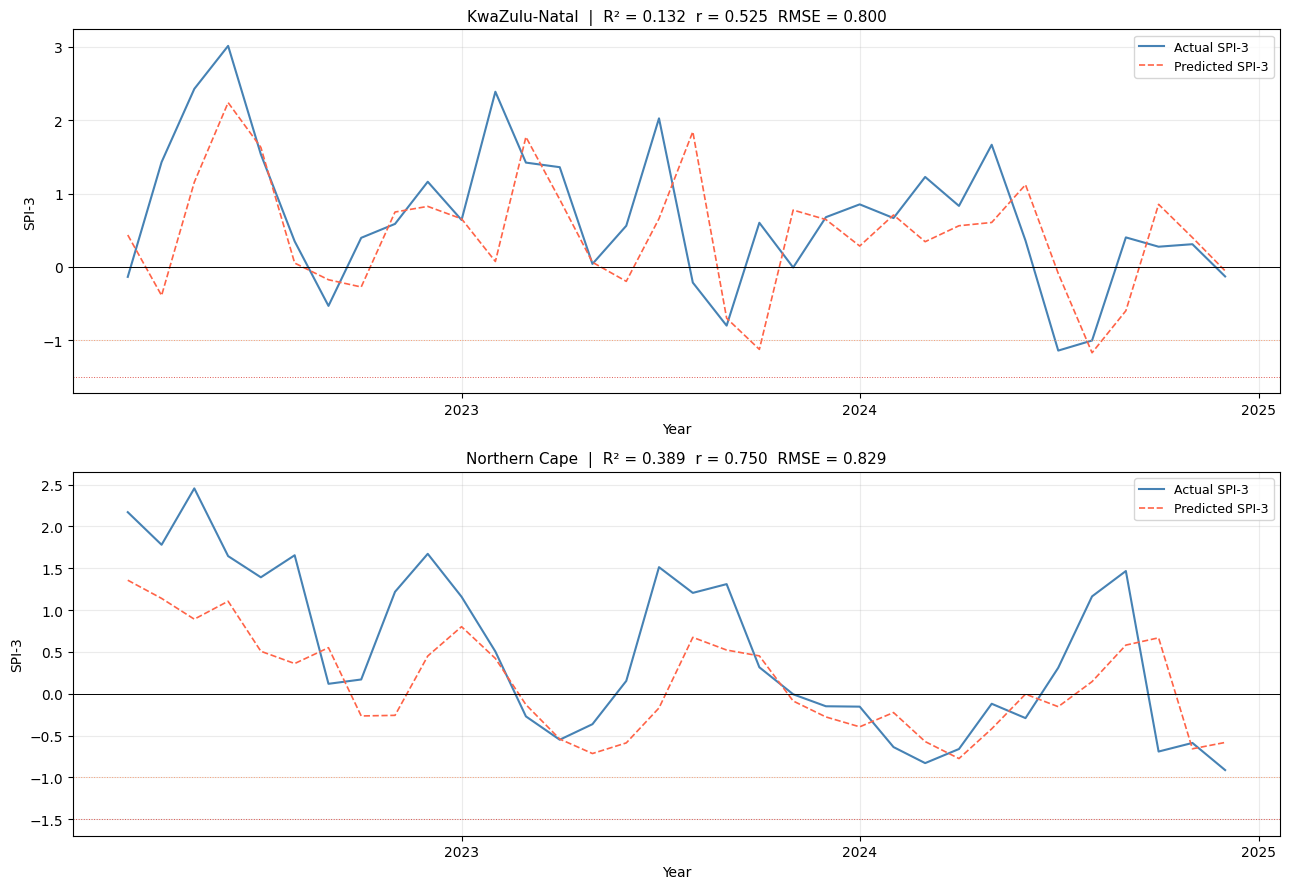

Saved: LSTM_prediction_vs_actual.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, (key, res) in zip(axes, lstm_results.items()):
    # align lengths — take the shorter of the two
    dates  = pd.to_datetime(res['test_dates'])
    y_true = res['y_true']
    y_pred = res['y_pred']
    n      = min(len(dates), len(y_true), len(y_pred))
    dates, y_true, y_pred = dates[-n:], y_true[-n:], y_pred[-n:]

    ax.plot(dates, y_true, color='steelblue',
            label='Actual SPI-3', linewidth=1.5)
    ax.plot(dates, y_pred, color='tomato',
            label='Predicted SPI-3', linewidth=1.2, linestyle='--')

    ax.axhline(0,    color='black',   linewidth=0.7)
    ax.axhline(-1.0, color='#fc8d59', linewidth=0.7, linestyle=':', alpha=0.8)
    ax.axhline(-1.5, color='#d73027', linewidth=0.7, linestyle=':', alpha=0.8)

    ax.set_title(
        f'{PROVINCES[key]["label"]}  |  R\u00b2 = {res["r2"]:.3f}  '
        f'r = {res["r"]:.3f}  RMSE = {res["rmse"]:.3f}',
        fontsize=11
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('SPI-3')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'LSTM_prediction_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: LSTM_prediction_vs_actual.png')

## Cell 18 — Figure: Scatter Plot

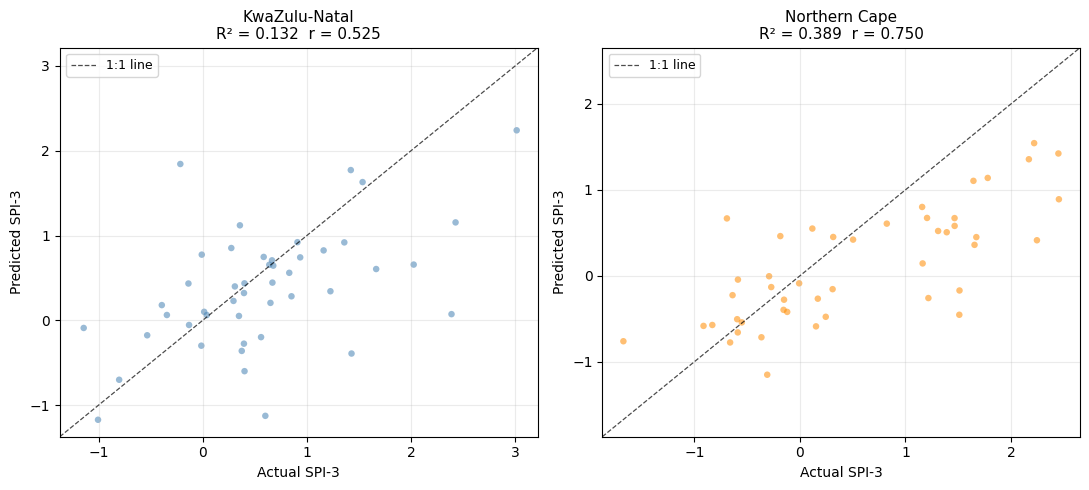

Saved: LSTM_scatter.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (key, res) in zip(axes, lstm_results.items()):
    n      = min(len(res['y_true']), len(res['y_pred']))
    y_true = res['y_true'][-n:]
    y_pred = res['y_pred'][-n:]

    ax.scatter(y_true, y_pred,
               color=PROVINCES[key]['color'], alpha=0.55, s=22, edgecolors='none')

    lims = [
        min(y_true.min(), y_pred.min()) - 0.2,
        max(y_true.max(), y_pred.max()) + 0.2
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.9, alpha=0.7, label='1:1 line')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel('Actual SPI-3', fontsize=10)
    ax.set_ylabel('Predicted SPI-3', fontsize=10)
    ax.set_title(
        f'{PROVINCES[key]["label"]}\nR\u00b2 = {res["r2"]:.3f}  r = {res["r"]:.3f}',
        fontsize=11
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'LSTM_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: LSTM_scatter.png')

## Cell 19 — Figure: Cross-Province Performance Comparison

A bar chart comparing R², Pearson r, and RMSE across the two provinces. The Northern Cape's stronger performance (higher R² and r) reflects the cleaner drought signal in an arid environment where rainfall variability is the dominant driver of vegetation response.

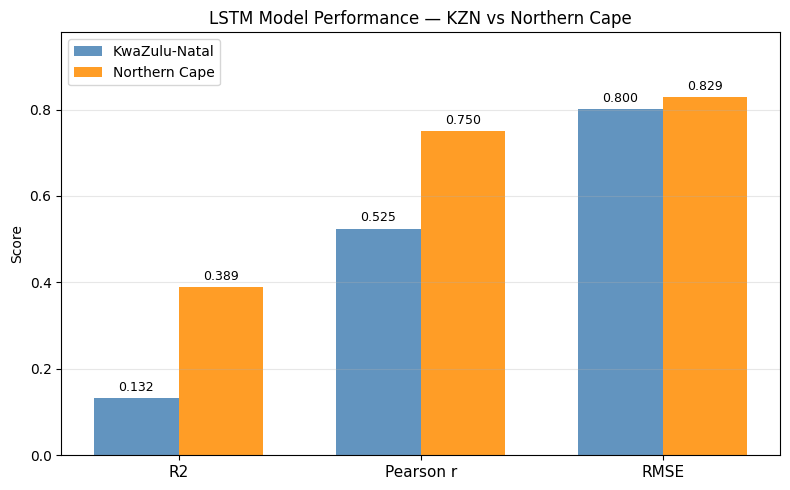

Saved: Province_comparison.png


In [ ]:
metrics   = ['R2', 'Pearson r', 'RMSE']
kzn_vals  = [lstm_results['KZN']['r2'],  lstm_results['KZN']['r'],  lstm_results['KZN']['rmse']]
nc_vals   = [lstm_results['NC']['r2'],   lstm_results['NC']['r'],   lstm_results['NC']['rmse']]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, kzn_vals, width,
               color=PROVINCES['KZN']['color'], label='KwaZulu-Natal', alpha=0.85)
bars2 = ax.bar(x + width/2, nc_vals,  width,
               color=PROVINCES['NC']['color'],  label='Northern Cape',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('LSTM Model Performance — KZN vs Northern Cape', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(kzn_vals), max(nc_vals)) + 0.15)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'Province_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Province_comparison.png')

## Cell 20 — Final Results Summary

In [ ]:
print('=' * 55)
print('  DROUGHT STUDY — FINAL RESULTS SUMMARY')
print('=' * 55)

print('\nSPI-3 Drought Characterisation')
print('-' * 55)
for key, info in PROVINCES.items():
    df = spi[key]
    worst = df.loc[df['spi3'].idxmin()]
    print(f'{info["label"]}:')
    print(f'  SPI-3 range:          {df["spi3"].min():.3f} to {df["spi3"].max():.3f}')
    print(f'  Worst month:          {worst["date"].strftime("%B %Y")} (SPI = {worst["spi3"]:.3f})')
    print(f'  Drought months (< -1.0): {(df["spi3"] < -1.0).sum()}')
    print(f'  Severe months (< -1.5):  {(df["spi3"] < -1.5).sum()}')
    print()

print('\nLSTM Prediction Performance')
print('-' * 55)
for key, res in lstm_results.items():
    print(f'{PROVINCES[key]["label"]}:')
    print(f'  RMSE:      {res["rmse"]:.4f}')
    print(f'  R2:        {res["r2"]:.4f}')
    print(f'  Pearson r: {res["r"]:.4f}')
    print(f'  Checkpoint: {os.path.basename(res["model_path"])}')
    print()

print('Figures saved to:')
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f'  {f}')

  DROUGHT STUDY — FINAL RESULTS SUMMARY

SPI-3 Drought Characterisation
-------------------------------------------------------
KwaZulu-Natal:
  SPI-3 range:          -2.436 to 3.015
  Worst month:          January 2016 (SPI = -2.436)
  Drought months (< -1.0): 56
  Severe months (< -1.5):  15

Northern Cape:
  SPI-3 range:          -2.161 to 2.454
  Worst month:          September 2017 (SPI = -2.161)
  Drought months (< -1.0): 48
  Severe months (< -1.5):  20


LSTM Prediction Performance
-------------------------------------------------------
KwaZulu-Natal:
  RMSE:      0.8003
  R2:        0.1318
  Pearson r: 0.5247
  Checkpoint: lstm_KZN.pth

Northern Cape:
  RMSE:      0.8285
  R2:        0.3888
  Pearson r: 0.7495
  Checkpoint: lstm_NC.pth

Figures saved to:
  LSTM_prediction_vs_actual.png
  LSTM_scatter.png
  LSTM_training_curves.png
  NDVI_anomaly_KZN.png
  NDVI_anomaly_NC.png
  Province_comparison.png
  SPI3_timeseries_KZN.png
  SPI3_timeseries_NC.png
  SPI_NDVI_combined_KZN.pn

In [ ]:
# ── Persistence baseline ──────────────────────────────────────────
for key in ['KZN', 'NC']:
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_dates = sequences[key]

    # persistence = last SPI-3 value in each input sequence
    persist_pred = X_te[:, -1, 0]   # shape (46,)

    from sklearn.metrics import mean_squared_error, r2_score
    from scipy.stats import pearsonr
    import numpy as np

    rmse_p = np.sqrt(mean_squared_error(y_te, persist_pred))
    r2_p   = r2_score(y_te, persist_pred)
    r_p    = pearsonr(y_te, persist_pred)[0]
    print(f'{PROVINCES[key]["label"]} persistence:')
    print(f'  RMSE={rmse_p:.4f}  R2={r2_p:.4f}  r={r_p:.4f}')
    print()

KwaZulu-Natal persistence:
  RMSE=0.1689  R2=-0.0968  r=0.4502

Northern Cape persistence:
  RMSE=0.1798  R2=0.4138  r=0.7039



In [ ]:
for key in ['KZN', 'NC']:
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_dates = sequences[key]

    persist_pred = X_te[:, -1, 0]   # normalised space

    # back-transform to SPI-3 units using the scaler
    # scaler was fit on [spi3, ndvi_anomaly], so SPI-3 is column 0
    spi3_min = scaler.data_min_[0]
    spi3_max = scaler.data_max_[0]

    persist_spi  = persist_pred  * (spi3_max - spi3_min) + spi3_min
    actual_spi   = y_te          * (spi3_max - spi3_min) + spi3_min

    rmse_p = np.sqrt(mean_squared_error(actual_spi, persist_spi))
    r2_p   = r2_score(actual_spi, persist_spi)
    r_p    = pearsonr(actual_spi, persist_spi)[0]

    print(f'{PROVINCES[key]["label"]} persistence (SPI-3 units):')
    print(f'  RMSE={rmse_p:.4f}  R2={r2_p:.4f}  r={r_p:.4f}')
    print()

KwaZulu-Natal persistence (SPI-3 units):
  RMSE=0.8995  R2=-0.0968  r=0.4502

Northern Cape persistence (SPI-3 units):
  RMSE=0.8114  R2=0.4138  r=0.7039

